In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [6]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

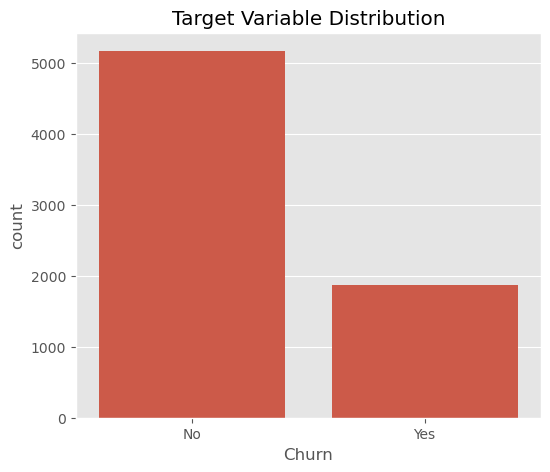

In [7]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Target Variable Distribution")

plt.show()

In [8]:
percentage = df["Churn"].value_counts(normalize=True)*100

print(percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [9]:
percentage = df["Churn"].value_counts(normalize=True)*100

print(percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [10]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [11]:
numerical = df.select_dtypes(include=np.number).columns.tolist()

categorical = df.select_dtypes(include="object").columns.tolist()

print("Numerical Features")

print(numerical)

print()

print("Categorical Features")

print(categorical)

Numerical Features
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [12]:
binary_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

encoder = LabelEncoder()

for col in binary_cols:
    df[col] = encoder.fit_transform(df[col])

In [13]:
remaining = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

df = pd.get_dummies(
    df,
    columns=remaining,
    drop_first=True
)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   object 
 1   gender                                 7043 non-null   int64  
 2   SeniorCitizen                          7043 non-null   int64  
 3   Partner                                7043 non-null   int64  
 4   Dependents                             7043 non-null   int64  
 5   tenure                                 7043 non-null   int64  
 6   PhoneService                           7043 non-null   int64  
 7   PaperlessBilling                       7043 non-null   int64  
 8   MonthlyCharges                         7043 non-null   float64
 9   TotalCharges                           7043 non-null   float64
 10  Churn                                  7043 non-null   int64  
 11  Mult

In [15]:
corr = df.corr(numeric_only=True)

corr

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
gender,1.000000,-0.001874,-0.001808,0.010517,0.005106,-0.006488,-0.011754,-0.014569,-0.000002,-0.008612,...,-0.009212,0.006026,-0.008393,0.006026,-0.010487,0.008026,-0.003695,0.001215,0.000752,0.013744
SeniorCitizen,-0.001874,1.000000,0.016479,-0.211185,0.016567,0.008576,0.156530,0.220173,0.102652,0.150889,...,-0.060625,-0.182742,0.105378,-0.182742,0.120176,-0.046262,-0.117000,-0.024135,0.171718,-0.153477
Partner,-0.001808,0.016479,1.000000,0.452676,0.379697,0.017706,-0.014877,0.096848,0.318364,-0.150448,...,0.119999,0.000615,0.124666,0.000615,0.117412,0.082783,0.248091,0.082029,-0.083852,-0.095125
Dependents,0.010517,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.111377,-0.113890,0.063593,-0.164221,...,0.063268,0.139812,-0.016558,0.139812,-0.039741,0.068368,0.204613,0.060267,-0.150642,0.059071
tenure,0.005106,0.016567,0.379697,0.159712,1.000000,0.008448,0.006152,0.247900,0.825464,-0.352229,...,0.324221,-0.039062,0.279756,-0.039062,0.286111,0.202570,0.558533,0.233006,-0.208363,-0.233852
PhoneService,-0.006488,0.008576,0.017706,-0.001762,0.008448,1.000000,0.016505,0.247398,0.113013,0.011942,...,-0.096340,0.172209,-0.022574,0.172209,-0.032959,-0.002791,0.003519,-0.007721,0.003062,-0.003319
PaperlessBilling,-0.011754,0.156530,-0.014877,-0.111377,0.006152,0.016505,1.000000,0.352150,0.158055,0.191825,...,0.037880,-0.321013,0.223841,-0.321013,0.211716,-0.051391,-0.147889,-0.013589,0.208865,-0.205398
MonthlyCharges,-0.014569,0.220173,0.096848,-0.113890,0.247900,0.247398,0.352150,1.000000,0.650864,0.193356,...,0.338304,-0.763557,0.629603,-0.763557,0.627429,0.004904,-0.074681,0.030550,0.271625,-0.377437
TotalCharges,-0.000002,0.102652,0.318364,0.063593,0.825464,0.113013,0.158055,0.650864,1.000000,-0.199037,...,0.432329,-0.374706,0.515279,-0.374706,0.519884,0.170649,0.356226,0.182745,-0.059971,-0.294814
Churn,-0.008612,0.150889,-0.150448,-0.164221,-0.352229,0.011942,0.191825,0.193356,-0.199037,1.000000,...,-0.164674,-0.227890,0.063228,-0.227890,0.061382,-0.177820,-0.302253,-0.134302,0.301919,-0.091683


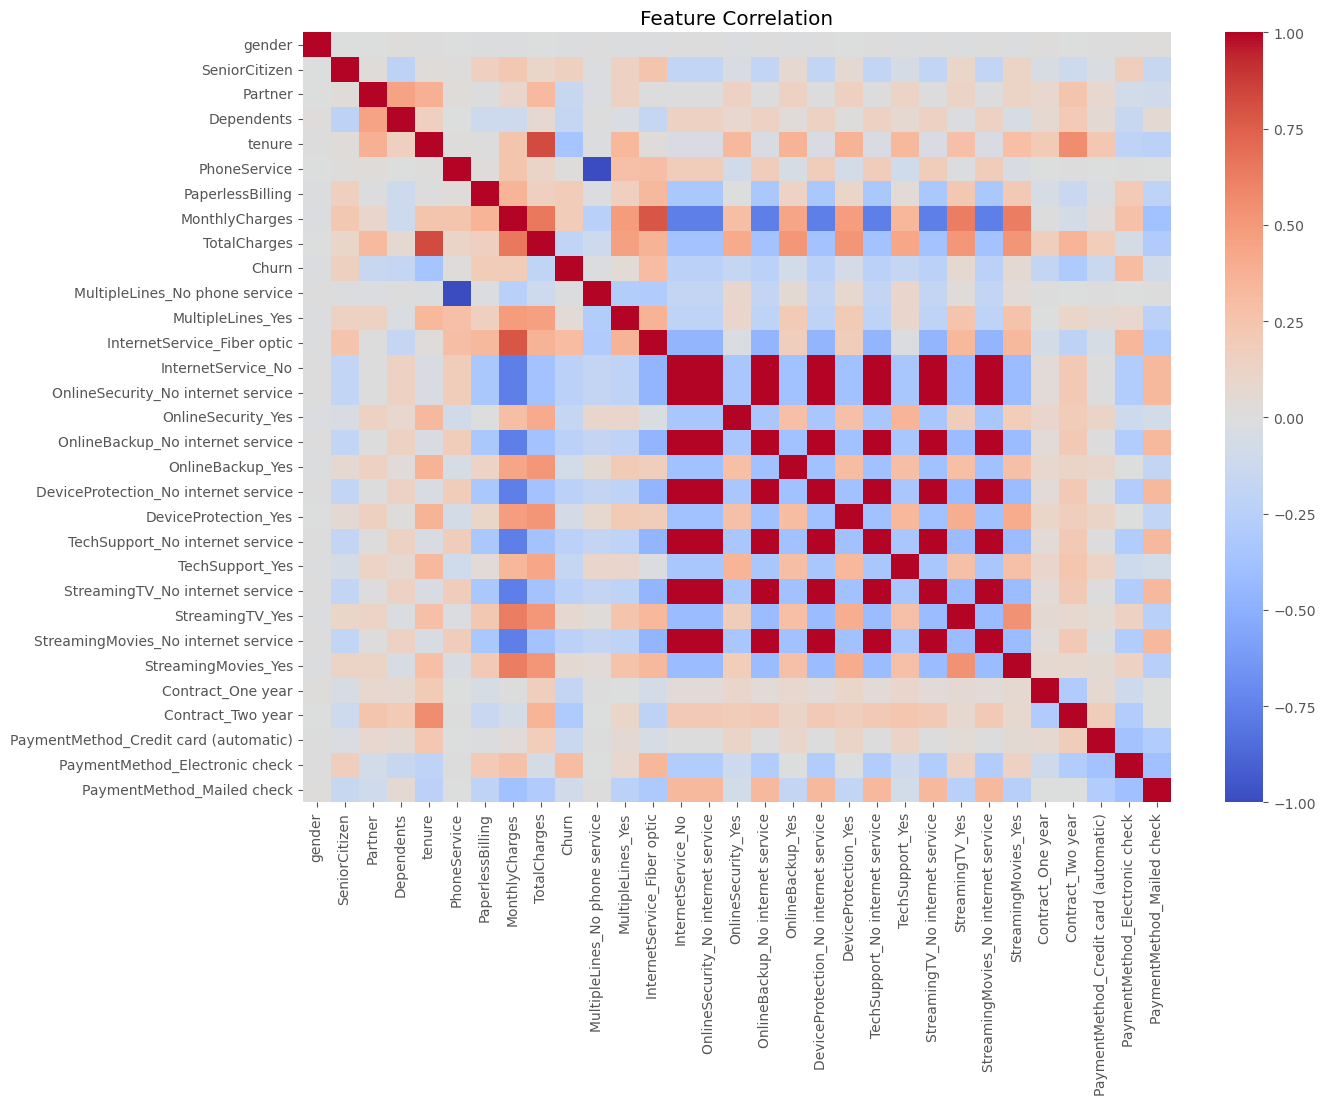

In [16]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation")

plt.show()

In [17]:
target_corr = (
    corr["Churn"]
    .sort_values(ascending=False)
)

print(target_corr)

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService                             0.011942
gender                                  -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


In [18]:
print("Top Positive Correlations")

print(target_corr.head(10))

print()

print("Top Negative Correlations")

print(target_corr.tail(10))

Top Positive Correlations
Churn                             1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling                  0.191825
SeniorCitizen                     0.150889
StreamingTV_Yes                   0.063228
StreamingMovies_Yes               0.061382
MultipleLines_Yes                 0.040102
PhoneService                      0.011942
Name: Churn, dtype: float64

Top Negative Correlations
TotalCharges                           -0.199037
OnlineSecurity_No internet service     -0.227890
OnlineBackup_No internet service       -0.227890
InternetService_No                     -0.227890
DeviceProtection_No internet service   -0.227890
TechSupport_No internet service        -0.227890
StreamingTV_No internet service        -0.227890
StreamingMovies_No internet service    -0.227890
Contract_Two year                      -0.302253
tenure                                 -0.352229

In [19]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [20]:
df.var(numeric_only=True).sort_values(ascending=False).head(10)

TotalCharges                   5.131450e+06
MonthlyCharges                 9.054109e+02
tenure                         6.031681e+02
gender                         2.500129e-01
Partner                        2.497476e-01
InternetService_Fiber optic    2.463851e-01
MultipleLines_Yes              2.439252e-01
PaperlessBilling               2.415299e-01
StreamingMovies_Yes            2.374680e-01
StreamingTV_Yes                2.366594e-01
dtype: float64

In [21]:
print("""
Machine Learning Problem Type

Target Variable : Churn

Prediction Type : Classification

Labels : Yes / No

Hence, this is a Supervised Binary Classification Problem.
""")


Machine Learning Problem Type

Target Variable : Churn

Prediction Type : Classification

Labels : Yes / No

Hence, this is a Supervised Binary Classification Problem.



In [23]:
algorithms = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost",
    "Gradient Boosting",
    "Support Vector Machine",
    "K-Nearest Neighbors"
]

for algo in algorithms:
    print(algo)

Logistic Regression
Decision Tree
Random Forest
XGBoost
Gradient Boosting
Support Vector Machine
K-Nearest Neighbors


In [24]:
important = target_corr.abs().sort_values(
    ascending=False
)

important.head(15)

Churn                                   1.000000
tenure                                  0.352229
InternetService_Fiber optic             0.308020
Contract_Two year                       0.302253
PaymentMethod_Electronic check          0.301919
TechSupport_No internet service         0.227890
OnlineSecurity_No internet service      0.227890
OnlineBackup_No internet service        0.227890
DeviceProtection_No internet service    0.227890
InternetService_No                      0.227890
StreamingTV_No internet service         0.227890
StreamingMovies_No internet service     0.227890
TotalCharges                            0.199037
MonthlyCharges                          0.193356
PaperlessBilling                        0.191825
Name: Churn, dtype: float64

In [26]:
print("""
Business Feasibility

✔ Historical customer data available

✔ Clear target variable

✔ Enough observations

✔ Structured dataset

✔ Predictive features available

✔ Business value is high

Machine Learning is feasible.
""")


Business Feasibility

✔ Historical customer data available

✔ Clear target variable

✔ Enough observations

✔ Structured dataset

✔ Predictive features available

✔ Business value is high

Machine Learning is feasible.



In [27]:
print("""
Technical Feasibility

✔ Data is structured

✔ Missing values handled

✔ Features encoded

✔ Numerical features available

✔ Classification algorithms applicable
""")


Technical Feasibility

✔ Data is structured

✔ Missing values handled

✔ Features encoded

✔ Numerical features available

✔ Classification algorithms applicable



In [28]:
print("""
Potential Challenges

• Class imbalance

• Overfitting

• Feature correlation

• Data drift

• Changing customer behaviour
""")


Potential Challenges

• Class imbalance

• Overfitting

• Feature correlation

• Data drift

• Changing customer behaviour



In [29]:
workflow = [
    "Data Cleaning",
    "Feature Engineering",
    "Train-Test Split",
    "Model Training",
    "Hyperparameter Tuning",
    "Model Evaluation",
    "Deployment"
]

for step in workflow:
    print(step)

Data Cleaning
Feature Engineering
Train-Test Split
Model Training
Hyperparameter Tuning
Model Evaluation
Deployment


In [30]:
print("""
Final Assessment

The Telco Customer Churn dataset is highly suitable
for supervised machine learning.

Recommended First Model

✔ Logistic Regression

Recommended Best Model

✔ Random Forest

✔ XGBoost
""")


Final Assessment

The Telco Customer Churn dataset is highly suitable
for supervised machine learning.

Recommended First Model

✔ Logistic Regression

Recommended Best Model

✔ Random Forest

✔ XGBoost

